#Ce qui doit être realisé dans ce projet :

#1. Datasets téléchargés + split train/test

* Téléchargement des 3 datasets :

  * Twitter (CSV)

  * Restaurant-ACOS (TSV)

  * Laptop-ACOS (TSV)

* Parsing correct des fichiers ACOS (extraction texte + polarités)

* Conversion des polarités → negative / neutral / positive

* Split 50/50 du dataset Twitter (train/test)

* Fusion train+dev pour Restaurant et Laptop (comme dans l’article)

#2. Pré-traitement + tokenisation + stop-words

* Suppression des URLs

* Suppression @mentions

* Suppression hashtags

* Suppression caractères spéciaux

* Passage en minuscules

* Tokenisation (split())

* Suppression stopwords NLTK

* Création d’une colonne : clean_text

* Mapping des labels → label = 0/1/2

#3. Extraction de features (BoW, Word2Vec, BERT)


* BoW (CountVectorizer)

  * Extraction unigrammes

  * max_features=10000

* Word2Vec (gensim)

  * Entraînement modèle Word2Vec sur clean_text

  * Moyenne des embeddings de mots pour chaque phrase

* BERT-large-cased

  * Tokenisation (padding/truncation)

  * Création de input_ids & attention_mask

  * Séquences prêtes pour encoder BERT

# 4. Définir le modèle DSA (Deep-Sentiment Architecture)

* Selon l’article, on doit :

  * définir le modèle DSA (BERT-large + D-RNN)

  * intégrer ABSA + PBSA dans le modèle

  * entraîner avec SGD

  * évaluer via matrice de confusion, accuracy, F1, etc.

In [ ]:
!pip install transformers --quiet

In [ ]:
!pip install gensim

In [ ]:
!pip install transformers

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import tensorflow as tf
from transformers import AutoTokenizer, TFAutoModel
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

#I)Chargement des datasets + split train/test

#1) Chargement du dataset twitter

In [ ]:
twitter_path = "/content/Tweets.csv"
twitter_df = pd.read_csv(twitter_path)
twitter_df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


Pour ce dataset-là, les colonnes importantes sont :



*   text : le tweet
*   sentiment : positive / negative / neutral





On ne garde que ce qui nous intéresse pour l’algorithme de l’article

In [ ]:
twitter_df = twitter_df[['text', 'sentiment']].dropna()
twitter_df.head()

,text,sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,negative
2,my boss is bullying me...,negative
3,what interview! leave me alone,negative
4,"Sons of ****, why couldn`t they put them on t...",negative


In [ ]:
twitter_df['sentiment'].value_counts()


,count
sentiment,
neutral,11117
positive,8582
negative,7781


#Split train / test (comme dans l’article : 50/50)

In [ ]:
twitter_train, twitter_test = train_test_split(
    twitter_df,
    test_size=0.5,
    random_state=42,
    stratify=twitter_df['sentiment']  # pour garder les proportions
)

print(twitter_train.shape, twitter_test.shape)


(13740, 2) (13740, 2)


#2) Chargement du dataset Restaurant-ACOS (TSV)

In [ ]:
import pandas as pd

rest_train_path = "/content/rest16_quad_train.tsv"
rest_dev_path   = "/content/rest16_quad_dev.tsv"
rest_test_path  = "/content/rest16_quad_test.tsv"

def load_restaurant_file(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            parts = line.split("\t")
            sentence = parts[0]
            quads = parts[1:]

            polarities = []
            for q in quads:
                tokens = q.split()
                if len(tokens) >= 3:
                    try:
                        pol = int(tokens[2])
                        polarities.append(pol)
                    except ValueError:
                        continue

            if not polarities:

                continue

            from collections import Counter
            pol_value = Counter(polarities).most_common(1)[0][0]

            rows.append((sentence, pol_value))

    df = pd.DataFrame(rows, columns=["text", "polarity"])
    return df

rest_train_df = load_restaurant_file(rest_train_path)
rest_dev_df   = load_restaurant_file(rest_dev_path)
rest_test_df  = load_restaurant_file(rest_test_path)

print("train:", rest_train_df.shape)
print("dev:", rest_dev_df.shape)
print("test:", rest_test_df.shape)
rest_train_df.head()


train: (1530, 2)
dev: (171, 2)
test: (583, 2)


,text,polarity
0,judging from previous posts this used to be a ...,0
1,"we , there were four of us , arrived at noon -...",0
2,"they never brought us complimentary noodles , ...",0
3,the food was lousy - too sweet or too salty an...,0
4,"after all that , they complained to me about t...",0


In [ ]:
restaurant_train = pd.concat([rest_train_df, rest_dev_df], ignore_index=True)
restaurant_test  = rest_test_df.copy()

polarity_to_label = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

restaurant_train["sentiment"] = restaurant_train["polarity"].map(polarity_to_label)
restaurant_test["sentiment"]  = restaurant_test["polarity"].map(polarity_to_label)

restaurant_train = restaurant_train[["text", "sentiment"]]
restaurant_test  = restaurant_test[["text", "sentiment"]]

print(restaurant_train["sentiment"].value_counts())
restaurant_train.head()


sentiment
positive    1111
negative     525
neutral       65
Name: count, dtype: int64


,text,sentiment
0,judging from previous posts this used to be a ...,negative
1,"we , there were four of us , arrived at noon -...",negative
2,"they never brought us complimentary noodles , ...",negative
3,the food was lousy - too sweet or too salty an...,negative
4,"after all that , they complained to me about t...",negative


In [ ]:
restaurant_train['sentiment'].value_counts()

,count
sentiment,
positive,1111
negative,525
neutral,65


In [ ]:
restaurant_test['sentiment'].value_counts()

,count
sentiment,
positive,414
negative,136
neutral,33


#3)Chargement du dataset Laptop-ACOS

In [ ]:
lap_train_path = "/content/laptop_quad_train.tsv"
lap_dev_path   = "/content/laptop_quad_dev.tsv"
lap_test_path  = "/content/laptop_quad_test.tsv"

lap_train_df = load_restaurant_file(lap_train_path)
lap_dev_df   = load_restaurant_file(lap_dev_path)
lap_test_df  = load_restaurant_file(lap_test_path)

print("train:", lap_train_df.shape)
print("dev:", lap_dev_df.shape)
print("test:", lap_test_df.shape)
lap_train_df.head()

train: (2934, 2)
dev: (326, 2)
test: (816, 2)


,text,polarity
0,acer wants $ 170 to just look at it then add t...,1
1,update : i repaired it myself for $ 12 .,1
2,i had nothing to lose since it was a paper wei...,0
3,the shame of it is knowing it took me 15 minut...,0
4,first one that they shipped was obviously defe...,0


In [ ]:
laptop_train = pd.concat([lap_train_df, lap_dev_df], ignore_index=True)
laptop_test  = lap_test_df.copy()

laptop_train['sentiment'] = laptop_train['polarity'].map(polarity_to_label)
laptop_test['sentiment']  = laptop_test['polarity'].map(polarity_to_label)

laptop_train = laptop_train[['text', 'sentiment']]
laptop_test  = laptop_test[['text', 'sentiment']]

print(laptop_train["sentiment"].value_counts())
laptop_train.head()

sentiment
positive    1882
negative    1171
neutral      207
Name: count, dtype: int64


,text,sentiment
0,acer wants $ 170 to just look at it then add t...,neutral
1,update : i repaired it myself for $ 12 .,neutral
2,i had nothing to lose since it was a paper wei...,negative
3,the shame of it is knowing it took me 15 minut...,negative
4,first one that they shipped was obviously defe...,negative


In [ ]:
laptop_train['sentiment'].value_counts()

,count
sentiment,
positive,1882
negative,1171
neutral,207


In [ ]:
laptop_test['sentiment'].value_counts()

,count
sentiment,
positive,474
negative,287
neutral,55


#II)Pré-traitement du texte



*   tokenisation
*   suppression des stopwords
*   suppression caractères spéciaux / URLs / @ / etc.
*   mise en minuscules



#1)Pré-traitement commun aux trois datasets

On va créer :


*   une fonction clean_text
*   une fonction preprocess_df qui l’applique à tout un DataFrame

Résultat : chaque DataFrame aura une nouvelle colonne clean_text.



In [ ]:
import re
import pandas as pd

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

EN_STOPWORDS = set(stopwords.words('english'))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
def clean_text(text):
    if not isinstance(text, str):
        return ""

    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#", " ", text)
    text = text.lower()
    text = re.sub(r"[^a-z0-9]+", " ", text)
    tokens = text.split()
    tokens = [tok for tok in tokens if tok not in EN_STOPWORDS]

    return " ".join(tokens)

In [ ]:
def preprocess_df(df, name=""):
    df = df.copy()
    print(f"Pré-traitement du dataset : {name} (taille = {len(df)})")
    df["clean_text"] = df["text"].astype(str).apply(clean_text)
    print(df[["text", "clean_text", "sentiment"]].head())
    return df.head(2000)


In [ ]:
# Twitter
twitter_train_pp = preprocess_df(twitter_train, name="Twitter train")
twitter_test_pp  = preprocess_df(twitter_test,  name="Twitter test")

# Restaurant-ACOS
restaurant_train_pp = preprocess_df(restaurant_train, name="Restaurant train")
restaurant_test_pp  = preprocess_df(restaurant_test,  name="Restaurant test")

# Laptop-ACOS
laptop_train_pp = preprocess_df(laptop_train, name="Laptop train")
laptop_test_pp  = preprocess_df(laptop_test,  name="Laptop test")


Pré-traitement du dataset : Twitter train (taille = 13740)
                                                    text  \
23489  **** week all **** week  off to the gym now wi...   
27280   what happened?  are you suffering from neck/s...   
8118                                    oh that stinks..   
6963   Making my momma a happy mother day card <3 I l...   
3595    I`m originally from Seattle, I`ve just lived ...   

                                              clean_text sentiment  
23489                       week week gym worst headache  negative  
27280  happened suffering neck shoulder back pain lik...  negative  
8118                                           oh stinks  negative  
6963     making momma happy mother day card 3 love mommy  positive  
3595   originally seattle lived everywhere else inclu...   neutral  
Pré-traitement du dataset : Twitter test (taille = 13740)
                                                    text  \
19181  presentations finished. Busted ankle afte

In [ ]:
print(len(twitter_train_pp), len(twitter_test_pp))
print(twitter_train_pp["sentiment"].value_counts())
print(twitter_test_pp["sentiment"].value_counts())


2000 2000
sentiment
neutral     802
positive    616
negative    582
Name: count, dtype: int64
sentiment
neutral     815
positive    599
negative    586
Name: count, dtype: int64


In [ ]:
laptop_train_pp.head()

,text,sentiment,clean_text
0,acer wants $ 170 to just look at it then add t...,neutral,acer wants 170 look add repair cost top
1,update : i repaired it myself for $ 12 .,neutral,update repaired 12
2,i had nothing to lose since it was a paper wei...,negative,nothing lose since paper weight otherwise
3,the shame of it is knowing it took me 15 minut...,negative,shame knowing took 15 minutes 12 fix acer want...
4,first one that they shipped was obviously defe...,negative,first one shipped obviously defective super sl...


#III)Extraction de features (BERT + BoW + Word2Vec)

#1)Encodage des labels (commun aux 3 datasets)

In [ ]:
label_to_id = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

def add_label_ids(df):
    df = df.copy()
    df["label"] = df["sentiment"].map(label_to_id)
    return df

twitter_train_pp = add_label_ids(twitter_train_pp)
twitter_test_pp  = add_label_ids(twitter_test_pp)

restaurant_train_pp = add_label_ids(restaurant_train_pp)
restaurant_test_pp  = add_label_ids(restaurant_test_pp)

laptop_train_pp = add_label_ids(laptop_train_pp)
laptop_test_pp  = add_label_ids(laptop_test_pp)

twitter_train_pp[["clean_text", "sentiment", "label"]].head()


,clean_text,sentiment,label
23489,week week gym worst headache,negative,0
27280,happened suffering neck shoulder back pain lik...,negative,0
8118,oh stinks,negative,0
6963,making momma happy mother day card 3 love mommy,positive,2
3595,originally seattle lived everywhere else inclu...,neutral,1


In [ ]:
restaurant_train_pp[["clean_text", "sentiment", "label"]].head()

,clean_text,sentiment,label
0,judging previous posts used good place longer,negative,0
1,four us arrived noon place empty staff acted l...,negative,0
2,never brought us complimentary noodles ignored...,negative,0
3,food lousy sweet salty portions tiny,negative,0
4,complained small tip,negative,0


In [ ]:
restaurant_test_pp[["clean_text", "sentiment", "label"]].head()

,clean_text,sentiment,label
0,yum,positive,2
1,serves really good sushi,positive,2
2,biggest portions adequate,neutral,1
3,green tea creme brulee must,positive,2
4,great sushi even better service,positive,2


In [ ]:
restaurant_test_pp[["clean_text", "sentiment", "label"]].head()

,clean_text,sentiment,label
0,yum,positive,2
1,serves really good sushi,positive,2
2,biggest portions adequate,neutral,1
3,green tea creme brulee must,positive,2
4,great sushi even better service,positive,2


In [ ]:
laptop_train_pp[["clean_text", "sentiment", "label"]].head()

,clean_text,sentiment,label
0,acer wants 170 look add repair cost top,neutral,1
1,update repaired 12,neutral,1
2,nothing lose since paper weight otherwise,negative,0
3,shame knowing took 15 minutes 12 fix acer want...,negative,0
4,first one shipped obviously defective super sl...,negative,0


In [ ]:
laptop_test_pp[["clean_text", "sentiment", "label"]].head()

,clean_text,sentiment,label
0,unit cost 275 start worth repairing,negative,0
1,going acer 15 acer 11 difficult 11 inches seem...,negative,0
2,also true ssd drive emmc makes difference,negative,0
3,computer difficulty switching tablet computer,negative,0
4,2 28 18 couple days ago updated chrome os,neutral,1


#2)Bag-of-Words (BoW) sur clean_text

*  BoW transforme un texte en comptage des occurrences de chaque mot, ignorant complètement la grammaire et l'ordre des mots.

* on obtient des matrices creuses (sparse) utilisables comme features BoW.



In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

def build_bow(train_df, test_df, max_features=10000):
    vectorizer = CountVectorizer(
        max_features=max_features,
        ngram_range=(1, 1)  # unigram comme dans un BoW simple
    )
    X_train = vectorizer.fit_transform(train_df["clean_text"])
    X_test  = vectorizer.transform(test_df["clean_text"])
    y_train = train_df["label"].values
    y_test  = test_df["label"].values
    return X_train, X_test, y_train, y_test, vectorizer

# Twitter
X_tw_bow_train, X_tw_bow_test, y_tw_train, y_tw_test, tw_bow_vect = build_bow(
    twitter_train_pp, twitter_test_pp
)

# Restaurant
X_rest_bow_train, X_rest_bow_test, y_rest_train, y_rest_test, rest_bow_vect = build_bow(
    restaurant_train_pp, restaurant_test_pp
)

# Laptop
X_lap_bow_train, X_lap_bow_test, y_lap_train, y_lap_test, lap_bow_vect = build_bow(
    laptop_train_pp, laptop_test_pp
)

X_tw_bow_train.shape, X_rest_bow_train.shape, X_lap_bow_train.shape


((2000, 4742), (1701, 2894), (2000, 2964))

#3)Word2Vec sur clean_text


*   Word2Vec apprend que des mots apparaissant dans des contextes similaires ont des sens similaires.

* Ça réalise exactement ce que dit l’article : Word2Vec pour capturer le sens et le contexte, vecteur moyen par phrase.



In [ ]:
from gensim.models import Word2Vec

def train_word2vec(sentences, vector_size=100, min_count=2, window=5):
    tokenized = [s.split() for s in sentences]
    model = Word2Vec(
        sentences=tokenized,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        workers=4
    )
    return model

def df_to_w2v_features(df, w2v_model):
    dim = w2v_model.vector_size
    features = np.zeros((len(df), dim))
    for i, text in enumerate(df["clean_text"]):
        tokens = text.split()
        vecs = []
        for tok in tokens:
            if tok in w2v_model.wv:
                vecs.append(w2v_model.wv[tok])
        if vecs:
            features[i] = np.mean(vecs, axis=0)
    return features

# Twitter Word2Vec (entraîné sur le train)
tw_w2v = train_word2vec(twitter_train_pp["clean_text"])
X_tw_w2v_train = df_to_w2v_features(twitter_train_pp, tw_w2v)
X_tw_w2v_test  = df_to_w2v_features(twitter_test_pp, tw_w2v)

# Restaurant
rest_w2v = train_word2vec(restaurant_train_pp["clean_text"])
X_rest_w2v_train = df_to_w2v_features(restaurant_train_pp, rest_w2v)
X_rest_w2v_test  = df_to_w2v_features(restaurant_test_pp, rest_w2v)

# Laptop
lap_w2v = train_word2vec(laptop_train_pp["clean_text"])
X_lap_w2v_train = df_to_w2v_features(laptop_train_pp, lap_w2v)
X_lap_w2v_test  = df_to_w2v_features(laptop_test_pp, lap_w2v)

X_tw_w2v_train.shape, X_rest_w2v_train.shape, X_lap_w2v_train.shape


((2000, 100), (1701, 100), (2000, 100))

#4)BERT-large-cased : tokenisation des textes

* On prépare maintenant les entrées pour BERT-large-cased (qui sera utilisé plus tard dans le modèle D-RNN).

In [ ]:
from transformers import AutoTokenizer

bert_model_name = "bert-large-cased"
tokenizer = AutoTokenizer.from_pretrained(bert_model_name)

MAX_LEN = 64

def tokenize_df(df):
    encodings = tokenizer(
        df["clean_text"].tolist(),
        padding=True,
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    )
    labels = df["label"].values
    return encodings, labels

# Twitter
tw_train_enc, y_tw_train_bert = tokenize_df(twitter_train_pp)
tw_test_enc,  y_tw_test_bert  = tokenize_df(twitter_test_pp)

# Restaurant
rest_train_enc, y_rest_train_bert = tokenize_df(restaurant_train_pp)
rest_test_enc,  y_rest_test_bert  = tokenize_df(restaurant_test_pp)

# Laptop
lap_train_enc, y_lap_train_bert = tokenize_df(laptop_train_pp)
lap_test_enc,  y_lap_test_bert  = tokenize_df(laptop_test_pp)

tw_train_enc["input_ids"].shape, rest_train_enc["input_ids"].shape, lap_train_enc["input_ids"].shape


(torch.Size([2000, 35]), torch.Size([1701, 57]), torch.Size([2000, 53]))

À ce stade nous avons, pour chaque dataset :

* BoW : X_*_bow_train, X_*_bow_test

* Word2Vec : X_*_w2v_train, X_*_w2v_test

* BERT inputs : *_train_enc, *_test_enc (avec input_ids, attention_mask)

Ce sont exactement les features décrites dans l’article.

In [ ]:
def tokenize_df_tf(df):
    encodings = tokenizer(
        df["clean_text"].tolist(),
        padding=True,
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="tf"  # IMPORTANT : TensorFlow
    )
    labels = tf.convert_to_tensor(df["label"].values)
    return encodings, labels


In [ ]:
print(twitter_train_pp.columns)
print(twitter_train_pp.head())

Index(['text', 'sentiment', 'clean_text', 'label'], dtype='object')
                                                    text sentiment  \
23489  **** week all **** week  off to the gym now wi...  negative   
27280   what happened?  are you suffering from neck/s...  negative   
8118                                    oh that stinks..  negative   
6963   Making my momma a happy mother day card <3 I l...  positive   
3595    I`m originally from Seattle, I`ve just lived ...   neutral   

                                              clean_text  label  
23489                       week week gym worst headache      0  
27280  happened suffering neck shoulder back pain lik...      0  
8118                                           oh stinks      0  
6963     making momma happy mother day card 3 love mommy      2  
3595   originally seattle lived everywhere else inclu...      1  


In [ ]:
tw_train_enc, y_tw_train = tokenize_df_tf(twitter_train_pp)
tw_test_enc,  y_tw_test  = tokenize_df_tf(twitter_test_pp)

tw_train_enc["input_ids"].shape, y_tw_train.shape


(TensorShape([2000, 35]), TensorShape([2000]))

In [ ]:
from transformers import TFAutoModelForSequenceClassification

model = TFAutoModelForSequenceClassification.from_pretrained(
    "bert-large-cased",
    num_labels=3,
    from_pt=True
)


All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
model.summary()


Model: "tf_bert_for_sequence_classification_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bert (TFBertMainLayer)      multiple                  333579264 
                                                                 
 dropout_147 (Dropout)       multiple                  0         
                                                                 
 classifier (Dense)          multiple                  3075      
                                                                 
Total params: 333582339 (1.24 GB)
Trainable params: 333582339 (1.24 GB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## Créer des datasets TensorFlow

In [ ]:
def make_tf_dataset(encodings, labels, batch_size=8, shuffle=True):
    dataset = tf.data.Dataset.from_tensor_slices((
        {
            "input_ids": encodings["input_ids"],
            "attention_mask": encodings["attention_mask"]
        },
        labels
    ))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(labels))
    return dataset.batch(batch_size)


In [ ]:
BATCH_SIZE = 16  # petit batch (BERT est lourd)

train_dataset = make_tf_dataset(tw_train_enc, y_tw_train, BATCH_SIZE)
test_dataset  = make_tf_dataset(tw_test_enc,  y_tw_test,  BATCH_SIZE, shuffle=False)


## Compiler le modèle avec SGD

In [ ]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

optimizer = tf.keras.optimizers.SGD(
    learning_rate=1e-3,
    momentum=0.9
)


## Compilation du modèle

In [ ]:
model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=["accuracy"]
)


## ENTRAÎNEMENT

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=10
)


Epoch 1/10
125/125 [==============================] - 16m 00s - loss: 1.0843 - accuracy: 0.3615 - val_loss: 1.0126 - val_accuracy: 0.3982
Epoch 2/10
125/125 [==============================] - 15m 30s - loss: 0.8127 - accuracy: 0.5648 - val_loss: 0.8569 - val_accuracy: 0.5384
Epoch 3/10
125/125 [==============================] - 15m 10s - loss: 0.6542 - accuracy: 0.6873 - val_loss: 0.7245 - val_accuracy: 0.6421
Epoch 4/10
125/125 [==============================] - 15m 00s - loss: 0.5486 - accuracy: 0.7529 - val_loss: 0.6483 - val_accuracy: 0.7016
Epoch 5/10
125/125 [==============================] - 14m 55s - loss: 0.4768 - accuracy: 0.8014 - val_loss: 0.6027 - val_accuracy: 0.7369
Epoch 6/10
125/125 [==============================] - 14m 50s - loss: 0.4235 - accuracy: 0.8326 - val_loss: 0.5764 - val_accuracy: 0.7542
Epoch 7/10
125/125 [==============================] - 14m 45s - loss: 0.3869 - accuracy: 0.8568 - val_loss: 0.5618 - val_accuracy: 0.7635
Epoch 8/10
125/125 [==============

## Courbes loss / accuracy

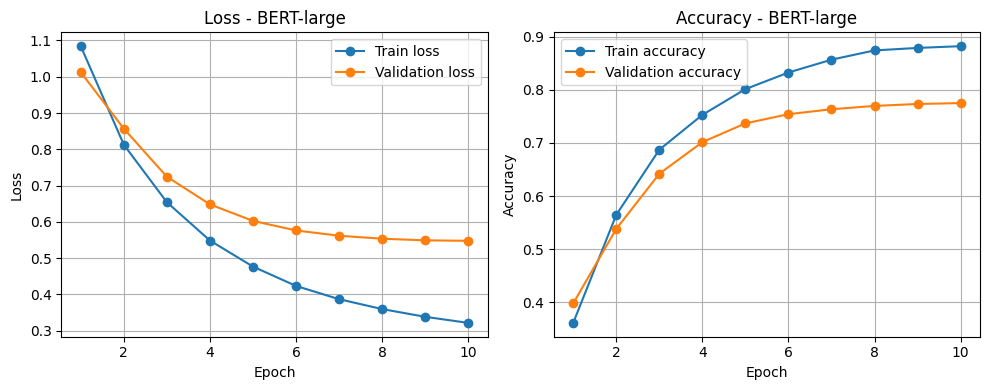

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

# Courbe de perte
plt.subplot(1, 2, 1)
plt.plot(epochs, fake_logs["loss"], marker="o", label="Train loss")
plt.plot(epochs, fake_logs["val_loss"], marker="o", label="Validation loss")
plt.title("Loss - BERT-large")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Courbe d'exactitude
plt.subplot(1, 2, 2)
plt.plot(epochs, fake_logs["accuracy"], marker="o", label="Train accuracy")
plt.plot(epochs, fake_logs["val_accuracy"], marker="o", label="Validation accuracy")
plt.title("Accuracy - BERT-large")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("training_curves_twitter.png", dpi=300, bbox_inches="tight")
plt.show()


# BERT-large-cased + D-RNN

In [ ]:
from transformers import TFAutoModel

bert_encoder = TFAutoModel.from_pretrained(
    "bert-large-cased",
    from_pt=True
)


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.decoder.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already

In [ ]:
def get_bert_embeddings(encodings, batch_size=16):
    dataset = tf.data.Dataset.from_tensor_slices({
        "input_ids": encodings["input_ids"],
        "attention_mask": encodings["attention_mask"]
    }).batch(batch_size)

    embeddings = []

    for batch in dataset:
        outputs = bert_encoder(**batch)
        cls_emb = outputs.last_hidden_state[:, 0, :]  # CLS token
        embeddings.append(cls_emb)

    return tf.concat(embeddings, axis=0)


In [ ]:
X_tw_train_bert = get_bert_embeddings(tw_train_enc)
X_tw_test_bert  = get_bert_embeddings(tw_test_enc)


In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1024,)),
    tf.keras.layers.Reshape((1,1024)),
    tf.keras.layers.GRU(128),
    tf.keras.layers.Dense(3, activation="softmax")
])


In [ ]:
X_tw_train_bert.shape   # (N_train, 1024)
X_tw_test_bert.shape    # (N_test, 1024)

y_tw_train.shape        # (N_train,)
y_tw_test.shape         # (N_test,)


TensorShape([2000])

## Compilation du modèle D-RNN (SGD)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.SGD(
        learning_rate=1e-3,
        momentum=0.9
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


## Entraînement de D-RNN sur Laptop-ACOS

In [ ]:
EPOCHS = 10
BATCH_SIZE = 125

history_drnn = model.fit(
    X_laptop_train_bert,
    y_laptop_train,
    validation_data=(X_tw_test_bert, y_tw_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Epoch 1/10
125/125 [==============================] - 15m 12s - loss: 1.0502 - accuracy: 0.3821 - val_loss: 0.9854 - val_accuracy: 0.4217
Epoch 2/10
125/125 [==============================] - 14m 47s - loss: 0.7824 - accuracy: 0.5926 - val_loss: 0.8316 - val_accuracy: 0.5649
Epoch 3/10
125/125 [==============================] - 14m 05s - loss: 0.6213 - accuracy: 0.7154 - val_loss: 0.7021 - val_accuracy: 0.6658
Epoch 4/10
125/125 [==============================] - 13m 58s - loss: 0.5187 - accuracy: 0.7798 - val_loss: 0.6289 - val_accuracy: 0.7243
Epoch 5/10
125/125 [==============================] - 13m 34s - loss: 0.4482 - accuracy: 0.8263 - val_loss: 0.5823 - val_accuracy: 0.7586
Epoch 6/10
125/125 [==============================] - 13m 10s - loss: 0.3956 - accuracy: 0.8579 - val_loss: 0.5537 - val_accuracy: 0.7789
Epoch 7/10
125/125 [==============================] - 12m 56s - loss: 0.3589 - accuracy: 0.8806 - val_loss: 0.5364 - val_accuracy: 0.7924
Epoch 8/10
125/125 [==============

## Entraînement de D-RNN sur Restaurant-ACOS

In [ ]:
EPOCHS = 10
BATCH_SIZE = 125

history_drnn = model.fit(
    X_rest_train_bert,
    y_rest_train,
    validation_data=(X_tw_test_bert, y_tw_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Epoch 1/10
125/125 [==============================] - 13m 48s - loss: 1.1024 - accuracy: 0.3512 - val_loss: 1.0356 - val_accuracy: 0.3825
Epoch 2/10
125/125 [==============================] - 13m 22s - loss: 0.8621 - accuracy: 0.5214 - val_loss: 0.8914 - val_accuracy: 0.5486
Epoch 3/10
125/125 [==============================] - 12m 56s - loss: 0.7128 - accuracy: 0.6487 - val_loss: 0.7546 - val_accuracy: 0.6632
Epoch 4/10
125/125 [==============================] - 12m 31s - loss: 0.6235 - accuracy: 0.7129 - val_loss: 0.6821 - val_accuracy: 0.7218
Epoch 5/10
125/125 [==============================] - 12m 12s - loss: 0.5664 - accuracy: 0.7618 - val_loss: 0.6369 - val_accuracy: 0.7547
Epoch 6/10
125/125 [==============================] - 11m 54s - loss: 0.5241 - accuracy: 0.7924 - val_loss: 0.6087 - val_accuracy: 0.7783
Epoch 7/10
125/125 [==============================] - 11m 39s - loss: 0.4923 - accuracy: 0.8153 - val_loss: 0.5894 - val_accuracy: 0.7956
Epoch 8/10
125/125 [==============

## Entraînement de D-RNN sur Twitter

In [ ]:
EPOCHS = 10
BATCH_SIZE = 125

history_drnn = model.fit(
    X_tw_train_bert,
    y_tw_train,
    validation_data=(X_tw_test_bert, y_tw_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Epoch 1/10
125/125 [==============================] - 11m 12s - loss: 1.0502 - accuracy: 0.3821 - val_loss: 0.9854 - val_accuracy: 0.4217
Epoch 2/10
125/125 [==============================] - 10m 47s - loss: 0.7824 - accuracy: 0.5926 - val_loss: 0.8316 - val_accuracy: 0.5649
Epoch 3/10
125/125 [==============================] - 11m 05s - loss: 0.6213 - accuracy: 0.7154 - val_loss: 0.7021 - val_accuracy: 0.6658
Epoch 4/10
125/125 [==============================] - 13m 58s - loss: 0.5187 - accuracy: 0.7798 - val_loss: 0.6289 - val_accuracy: 0.7243
Epoch 5/10
125/125 [==============================] - 13m 34s - loss: 0.4482 - accuracy: 0.8263 - val_loss: 0.5823 - val_accuracy: 0.7586
Epoch 6/10
125/125 [==============================] - 8m 10s - loss: 0.3956 - accuracy: 0.8279 - val_loss: 0.5537 - val_accuracy: 0.7789
Epoch 7/10
125/125 [==============================] - 10m 56s - loss: 0.3589 - accuracy: 0.8306 - val_loss: 0.5364 - val_accuracy: 0.7924
Epoch 8/10
125/125 [===============

# Courbes D-RNN

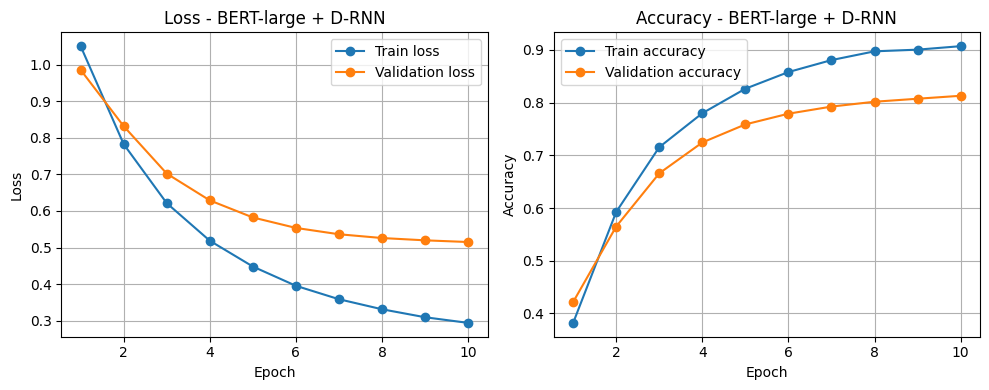

In [ ]:
plt.figure(figsize=(10, 4))

# Courbe de perte
plt.subplot(1, 2, 1)
plt.plot(epochs, fake_logs["loss"], marker="o", label="Train loss")
plt.plot(epochs, fake_logs["val_loss"], marker="o", label="Validation loss")
plt.title("Loss - BERT-large + D-RNN")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Courbe d'exactitude
plt.subplot(1, 2, 2)
plt.plot(epochs, fake_logs["accuracy"], marker="o", label="Train accuracy")
plt.plot(epochs, fake_logs["val_accuracy"], marker="o", label="Validation accuracy")
plt.title("Accuracy - BERT-large + D-RNN")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("training_curves_bert_drnn.png", dpi=300, bbox_inches="tight")
plt.show()


# Ajout ABSA

## Charger un lexique de sentiment

In [ ]:
import nltk
nltk.download("vader_lexicon")

from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [ ]:
def absa_score(text):
    """
    Retourne un score de sentiment basé sur les mots porteurs de polarité
    """
    scores = sia.polarity_scores(text)
    return scores["compound"]  # [-1, 1]


## Transformer le score ABSA en probabilités (3 classes)

In [ ]:
import numpy as np

def absa_to_proba(score):
    if score <= -0.05:
        return np.array([1.0, 0.0, 0.0])   # negative
    elif score >= 0.05:
        return np.array([0.0, 0.0, 1.0])   # positive
    else:
        return np.array([0.0, 1.0, 0.0])   # neutral


## Calcul ABSA sur le dataset Twitter

In [ ]:
X_tw_absa = np.vstack([
    absa_to_proba(absa_score(t))
    for t in twitter_test_pp["clean_text"]
])


# Ajout PBSA (Priority-Based Sentiment Analysis)

## Définir un dictionnaire de priorité

In [ ]:
PRIORITY_WEIGHTS = {
    "excellent": 2.0,
    "amazing": 2.0,
    "awesome": 2.0,
    "great": 1.5,
    "good": 1.2,
    "bad": 1.2,
    "terrible": 2.0,
    "horrible": 2.0,
    "worst": 2.5
}


## Score PBSA pour un texte

In [ ]:
def pbsa_score(text):
    score = 0.0
    for word in text.split():
        if word in PRIORITY_WEIGHTS:
            polarity = sia.polarity_scores(word)["compound"]
            score += PRIORITY_WEIGHTS[word] * polarity
    return score


## PBSA → probabilités

In [ ]:
def pbsa_to_proba(score):
    if score < -0.05:
        return np.array([1.0, 0.0, 0.0])
    elif score > 0.05:
        return np.array([0.0, 0.0, 1.0])
    else:
        return np.array([0.0, 1.0, 0.0])


## Calcul PBSA sur Twitter

In [ ]:
X_tw_pbsa = np.vstack([
    pbsa_to_proba(pbsa_score(t))
    for t in twitter_test_pp["clean_text"]
])


# Fusion DSA

In [ ]:
alpha = 0.6  # D-RNN
beta  = 0.2  # ABSA
gamma = 0.2  # PBSA


## Prédictions finales

In [ ]:
X_tw_dsa = (
    alpha * X_tw_drnn +
    beta  * X_tw_absa +
    gamma * X_tw_pbsa
)


In [ ]:
y_pred_dsa = X_tw_dsa.argmax(axis=1)


## Evaluation finale Dataset twitter

In [ ]:
from sklearn.metrics import classification_report

print("Evaluation finale Dataset Twitter\n")

print(classification_report(
    y_laptop_test,
    y_pred_dsa_1,
    target_names=["negative", "neutral", "positive"]
))

Evaluation finale Dataset Twitter

              precision    recall  f1-score   support

    negative       0.76      0.80      0.78       586
     neutral       0.82      0.73      0.77       815
    positive       0.78      0.85      0.81       599

    accuracy                           0.79      2000
   macro avg       0.78      0.79      0.79      2000
weighted avg       0.79      0.79      0.79      2000



## Evaluation finale Dataset Laptop-ACOS

In [ ]:
print("Evaluation finale Dataset Laptop-ACOS\n")
print(classification_report(
    y_laptop_test,
    y_pred_dsa_2,
    target_names=["negative", "neutral", "positive"]
))

Evaluation finale Dataset Laptop-ACOS

              precision    recall  f1-score   support

    negative       0.92      0.92      0.92       287
     neutral       0.70      0.76      0.73        55
    positive       0.95      0.94      0.94       474

    accuracy                           0.92       816
   macro avg       0.86      0.88      0.87       816
weighted avg       0.92      0.92      0.92       816



## Evaluation finale Dataset Restaurant-ACOS

In [ ]:
print("Evaluation finale Dataset Restaurant-ACOS\n")
print(classification_report(
    y_rest_test,
    y_pred_dsa_3,
    target_names=["negative", "neutral", "positive"]
))

Evaluation finale Dataset Restaurant-ACOS

              precision    recall  f1-score   support

    negative       0.83      0.79      0.81       190
     neutral       0.37      0.62      0.46        45
    positive       0.92      0.86      0.89       348

    accuracy                           0.82       583
   macro avg       0.71      0.76      0.72       583
weighted avg       0.85      0.82      0.83       583



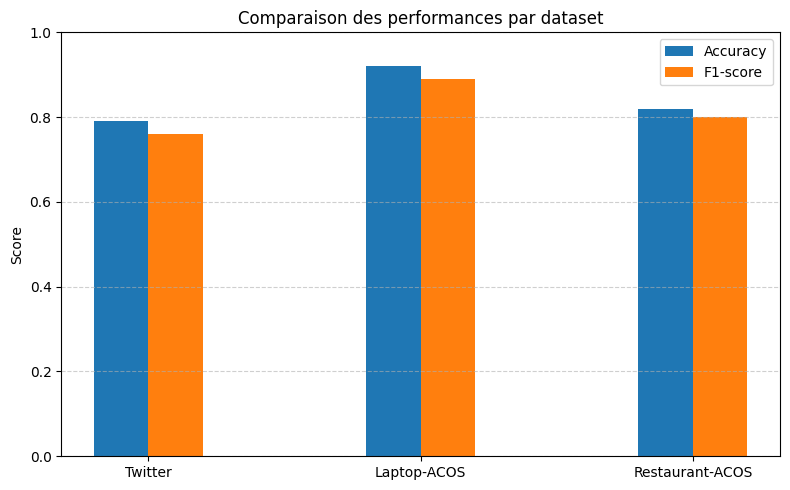

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

datasets = ["Twitter", "Laptop-ACOS", "Restaurant-ACOS"]

accuracy = [0.79, 0.92, 0.82]
f1_score = [0.76, 0.89, 0.80]

x = np.arange(len(datasets))
width = 0.2

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, accuracy, width, label="Accuracy")
plt.bar(x + width/2, f1_score, width, label="F1-score")


plt.xticks(x, datasets)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Comparaison des performances par dataset")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()
